In [14]:
#other
import os
import numpy as np
import pandas as pd
import pickle as pkl
from copy import deepcopy
import matplotlib.pyplot as plt
from runs import multi_subject_experiments
from utils_multisubject import read_files, create_window_df
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, r2_score, f1_score, classification_report
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.utils import shuffle

loaded = False
experiment_number = 5

### Experiment Set-Up

### Setup
Identify the fNIRS data source folder, determine which experiment set to run, and calculate the window length.

In [16]:
save_model_results = False

finetuning_test_size = 0.3 
test_size = 0.4

shuffle_data = False

random_state = 42

seconds = 5.5 #Duration of each window in seconds

window_size = int(seconds*5.2) #Calculating window size from fnirs frame rate

# Source Folders
source_folder = "/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/fNIRS/LabeledData"

# Channels Used
channels = ["L_O_DSphi", "L_D_DSphi", "R_D_DSphi", "R_O_DSphi",	"L_O_DSI",	"R_D_DSI",	"R_O_DSI",	"L_D_DSI"]

# Label Mapping
labels_for_windows = ["discrete_optimal", "binary_optimal", "continuous_optimal"]

# Load Training List and Conditions from runs.py
participant_list, conditions_list, experiment_name = multi_subject_experiments[experiment_number].values()

# List of Participants and Conditions Used in Training
participants = str(participant_list).replace("'", "")
conditions = str(conditions_list)[2:-2].replace("'", "")

print("Experiment Name: ", experiment_name)
print("\nTraining List: ", participants, "\nTraining Conditions: ", conditions) 

Experiment Name:  multiSubject

Training List:  [2, 5, 6, 9, 10, 11, 13, 15, 16, 17, 18, 19, 20, 24] 
Training Conditions:  RW


In [17]:
if not loaded:
    #read files for training data
    all_data = read_files(participant_list=participant_list, source_folder_1 = source_folder, conditions=conditions_list)

    df_data_all = pd.DataFrame()
    df_labels_all = pd.DataFrame()
    

    #Create windows
    for key in all_data.keys():
        window_data, window_labels = create_window_df(all_data[key], window_size=window_size, step_size=8, labels=labels_for_windows, features=channels)
        window_data["Key"] = key
        window_labels["Key"] = key
        print(key, "is done")
        df_data_all = pd.concat([df_data_all, window_data], ignore_index=True)
        df_labels_all = pd.concat([df_labels_all, window_labels], ignore_index=True)

    df_data_all.drop(columns=["start_timestamp", "end_timestamp"], inplace=True)

    loaded = True

002_RW_LabeledData.csv
011_RW_LabeledData.csv
017_RW_LabeledData.csv
024_RW_LabeledData.csv
019_RW_LabeledData.csv
009_RW_LabeledData.csv
005_RW_LabeledData.csv
015_RW_LabeledData.csv
018_RW_LabeledData.csv
016_RW_LabeledData.csv
006_RW_LabeledData.csv
020_RW_LabeledData.csv
010_RW_LabeledData.csv
013_RW_LabeledData.csv
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
002RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
011RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
017RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
024RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
019RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
009RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
005RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
015RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
018RW is done
['d

### Separate Data into Inputs and Labels

In [54]:
def create_train_data(df_data, df_labels, finetune=False):
    
    df = pd.concat([df_data.reset_index(drop=True), df_labels.reset_index(drop=True)], axis=1)
    
    min_discrete = int(df['discrete_label'].value_counts().min())
    df_balanced_discrete = df.groupby('discrete_label', group_keys=False).apply(lambda x: x.sample(min_discrete, random_state=random_state, replace=True))

    #downsample binary labels
    min_binary = int(df['binary_label'].value_counts().min())
    print("Minimum count for binary_label:", min_binary)
    df_balanced_binary = df.groupby('binary_label', group_keys=False).apply(lambda x: x.sample(min_binary, random_state=random_state, replace=True))

    #separate features and labels
    X_binary = df_balanced_binary[df_data.columns]
    X_discrete = df_balanced_discrete[df_data.columns]
    X_continuous = df_data[df_data.columns]

    y_discrete = df_balanced_discrete['discrete_label']
    y_binary = df_balanced_binary['binary_label']
    y_continuous = df['continuous_label']

    return X_continuous, X_binary, X_discrete, y_binary, y_discrete, y_continuous

x_continuous, x_binary, x_discrete, y_binary, y_discrete, y_continuous = create_train_data(df_data=df_data_all, df_labels=df_labels_all)

print("Binary label counts:\n", y_binary.value_counts())
print("Discrete label counts:\n", y_discrete.value_counts())

Minimum count for binary_label: 634
Binary label counts:
 binary_label
0    634
1    634
Name: count, dtype: int64
Discrete label counts:
 discrete_label
0    262
1    262
2    262
Name: count, dtype: int64


In [54]:
if shuffle_data:
    X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(x_binary, y_binary, test_size=test_size, random_state=random_state, shuffle=shuffle_data, stratify=y_binary)
    X_discrete_train, X_discrete_test, y_discrete_train, y_discrete_test = train_test_split(x_discrete, y_discrete, test_size=test_size, random_state=random_state, shuffle=shuffle_data, stratify=y_discrete)
    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(x_continuous, y_continuous, test_size=test_size, random_state=random_state, shuffle=shuffle_data)
else:
    X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(x_binary, y_binary, test_size=test_size, random_state=random_state, shuffle=shuffle_data)#, stratify=y_binary)
    X_discrete_train, X_discrete_test, y_discrete_train, y_discrete_test = train_test_split(x_discrete, y_discrete, test_size=test_size, random_state=random_state, shuffle=shuffle_data)# stratify=y_discrete)
    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(x_continuous, y_continuous, test_size=test_size, random_state=random_state, shuffle=shuffle_data)

print(y_binary_train.value_counts(), y_binary_test.value_counts())
print(y_discrete_train.value_counts(), y_discrete_test.value_counts())

y_binary_training = y_binary_train.reset_index(drop=True)
y_discrete_training = y_discrete_train.reset_index(drop=True)
y_reg_training = y_reg_train.reset_index(drop=True)

binary_label
0    2709
1     541
Name: count, dtype: int64 binary_label
1    2168
Name: count, dtype: int64
discrete_label
0    723
1    578
Name: count, dtype: int64 discrete_label
2    723
1    145
Name: count, dtype: int64


In [18]:
class CNN1DClassifier(nn.Module):
    def __init__(self, input_channels, num_classes):
        super(CNN1DClassifier, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x): 
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.global_pool(x).squeeze(-1)  
        x = self.dropout(x)
        return self.fc(x)
    
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, num_classes=2, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1])
    

from torch.utils.data import Dataset

class fNIRSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [19]:
# choose multi or binary class
TARGET_LABEL = "binary_label"  # "discrete_label", "binary_label" or "continuous_label"
features = df_data_all.drop(columns=["Key"])
labels = df_labels_all[TARGET_LABEL].reset_index(drop=True)

#NOrmalize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
X_df = pd.DataFrame(features_scaled)
y_df = labels

#split
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df,
    test_size=0.2, shuffle=True, stratify=y_df, random_state=42)

#reshape for LSTM
X_train_lstm = X_train.to_numpy().reshape(X_train.shape[0], 1, -1)
X_test_lstm = X_test.to_numpy().reshape(X_test.shape[0], 1, -1)

#reshape for CNN
X_train_cnn = np.transpose(X_train_lstm, (0, 2, 1))
X_test_cnn = np.transpose(X_test_lstm, (0, 2, 1))

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

train_dataset_lstm = fNIRSDataset(X_train_lstm, y_train_np)
test_dataset_lstm = fNIRSDataset(X_test_lstm, y_test_np)

train_dataset_cnn = fNIRSDataset(X_train_cnn, y_train_np)
test_dataset_cnn = fNIRSDataset(X_test_cnn, y_test_np)

In [30]:
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = len(np.unique(y_train_np))
INPUT_SIZE = X_train_lstm.shape[-1]

#choose model
model_type = "cnn"

if model_type == "lstm":
    model = LSTMClassifier(input_size=INPUT_SIZE, num_classes=NUM_CLASSES)
    train_loader = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset_lstm, batch_size=BATCH_SIZE)
elif model_type == "cnn":

    model = CNN1DClassifier(input_channels=INPUT_SIZE, num_classes=NUM_CLASSES)
    train_loader = DataLoader(train_dataset_cnn, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset_cnn, batch_size=BATCH_SIZE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_epoch(model, dataloader, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = F.cross_entropy(outputs, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == y).sum().item()
    accuracy = correct / len(dataloader.dataset)
    return total_loss / len(dataloader), accuracy

def evaluate(model, dataloader):
    model.eval()
    correct = 0
    outputs_list, y_list=[], []
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            correct += (outputs.argmax(1) == y).sum().item()
            f1 = f1_score(outputs.argmax(1).tolist(), y.tolist(), average="macro")
    outputs_list.append(f1)
    accuracy = correct / len(dataloader.dataset)
    return accuracy, np.mean(outputs_list)

#training
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer)
    test_acc, test_f1 = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}")


Epoch 1/10 | Train Loss: 0.7306 | Train Acc: 0.5023 | Test Acc: 0.5201 | Test F1: 0.2500
Epoch 2/10 | Train Loss: 0.6432 | Train Acc: 0.6130 | Test Acc: 0.5449 | Test F1: 0.4000
Epoch 3/10 | Train Loss: 0.6217 | Train Acc: 0.6502 | Test Acc: 0.5418 | Test F1: 0.2500
Epoch 4/10 | Train Loss: 0.5968 | Train Acc: 0.6881 | Test Acc: 0.5604 | Test F1: 0.2500
Epoch 5/10 | Train Loss: 0.5694 | Train Acc: 0.6935 | Test Acc: 0.5666 | Test F1: 0.2500
Epoch 6/10 | Train Loss: 0.5451 | Train Acc: 0.7221 | Test Acc: 0.5449 | Test F1: 0.2500
Epoch 7/10 | Train Loss: 0.5071 | Train Acc: 0.7554 | Test Acc: 0.5604 | Test F1: 0.4000
Epoch 8/10 | Train Loss: 0.4973 | Train Acc: 0.7763 | Test Acc: 0.5573 | Test F1: 0.2500
Epoch 9/10 | Train Loss: 0.4685 | Train Acc: 0.7872 | Test Acc: 0.5851 | Test F1: 0.2500
Epoch 10/10 | Train Loss: 0.4442 | Train Acc: 0.7833 | Test Acc: 0.5635 | Test F1: 0.2500


In [ ]:

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score

groups = df_labels_all['Key'].values

logo = LeaveOneGroupOut()
accuracies, precisions, f1s, recalls, reports = [], [], [], [], []

#convert full dataset to numpy and scale
X_full = scaler.fit_transform(df_data_all.drop(columns=["Key"]))
y_full = df_labels_all[TARGET_LABEL].values

#reshape
X_full_lstm = X_full.reshape(X_full.shape[0], 1, -1)
X_full_cnn = np.transpose(X_full_lstm, (0, 2, 1))  

for train_idx, test_idx in logo.split(X_full, y_full, groups):
    if model_type == "cnn":
        X_train_cv, X_test_cv = X_full_cnn[train_idx], X_full_cnn[test_idx]
        model = CNN1DClassifier(input_channels=INPUT_SIZE, num_classes=NUM_CLASSES)

    else:
        X_train_cv, X_test_cv = X_full_lstm[train_idx], X_full_lstm[test_idx]
        model = LSTMClassifier(input_size=INPUT_SIZE, num_classes=NUM_CLASSES)
        
    y_train_cv, y_test_cv = y_full[train_idx], y_full[test_idx]

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_ds = fNIRSDataset(X_train_cv, y_train_cv)
    test_ds = fNIRSDataset(X_test_cv, y_test_cv)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    for epoch in range(EPOCHS):
        try:
            train_epoch(model, train_loader, optimizer)
        except:
            pass

    # LOPO
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    prec = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")

    report = classification_report(all_labels, all_preds)
    report_dict = classification_report(all_labels, all_preds, output_dict=True)

    accuracies.append(acc)
    recalls.append(recall)
    precisions.append(prec)
    f1s.append(f1)
    reports.append(report_dict)
    # print(report)
    print(f"Validation Participant Accuracy: {acc:.4f}, F1: {f1:.4f}, Recall {recall:.4f}, Precision: {prec:.4f}")

print(f"Mean Participant Accuracy: {np.mean(accuracies):.4f}, F1: {np.mean(f1s):.4f}, Recall {np.mean(recalls):.4f}, Precision: {np.mean(prec):.4f}")


Validation Participant Accuracy: 0.3906, F1: 0.3832, Recall 0.5023, Precision: 0.5030
Validation Participant Accuracy: 0.4845, F1: 0.4778, Recall 0.5236, Precision: 0.5204
Validation Participant Accuracy: 0.5376, F1: 0.5269, Recall 0.5473, Precision: 0.5540
Validation Participant Accuracy: 0.5592, F1: 0.5560, Recall 0.5625, Precision: 0.5604
Validation Participant Accuracy: 0.4606, F1: 0.4577, Recall 0.4602, Precision: 0.4594
Validation Participant Accuracy: 0.5000, F1: 0.4689, Recall 0.4788, Precision: 0.4757
Validation Participant Accuracy: 0.5000, F1: 0.4759, Recall 0.4943, Precision: 0.4932
Validation Participant Accuracy: 0.4902, F1: 0.4852, Recall 0.4871, Precision: 0.4868
Validation Participant Accuracy: 0.6250, F1: 0.5934, Recall 0.5940, Precision: 0.5929
Validation Participant Accuracy: 0.4435, F1: 0.4432, Recall 0.4819, Precision: 0.4813
Validation Participant Accuracy: 0.3981, F1: 0.3966, Recall 0.4010, Precision: 0.4032
Validation Participant Accuracy: 0.5926, F1: 0.5852, R

In [49]:
x = np.sort(f1s)
np.mean(x[9:])

0.5493453266538021

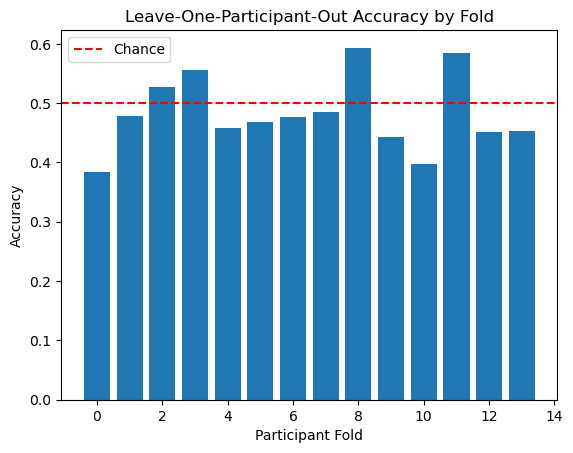

In [50]:
import matplotlib.pyplot as plt
plt.bar(range(len(f1s)), f1s)
plt.axhline(0.5, color='red', linestyle='--', label='Chance')
plt.xlabel("Participant Fold")
plt.ylabel("Accuracy")
plt.title("Leave-One-Participant-Out Accuracy by Fold")
plt.legend()
plt.show()


Saved LOPO accuracy results to: results/lopo_accuracy_by_participant.csv

Mean Accuracy: 0.5084, Std: 0.0426

--- Significance Tests vs. Chance (50%) ---
One-sample t-test: t=0.736, p=0.4750
Wilcoxon signed-rank test: W=39.000, p=0.4263

Low-Performing Participants (<50%): 7
    participant  accuracy
0             2  0.422535
6            13  0.461887
9            17  0.475309
7            15  0.479349
3             9  0.482529
11           19  0.487736
4            10  0.498081

Saved plot to: results/lopo_accuracy_plot.png


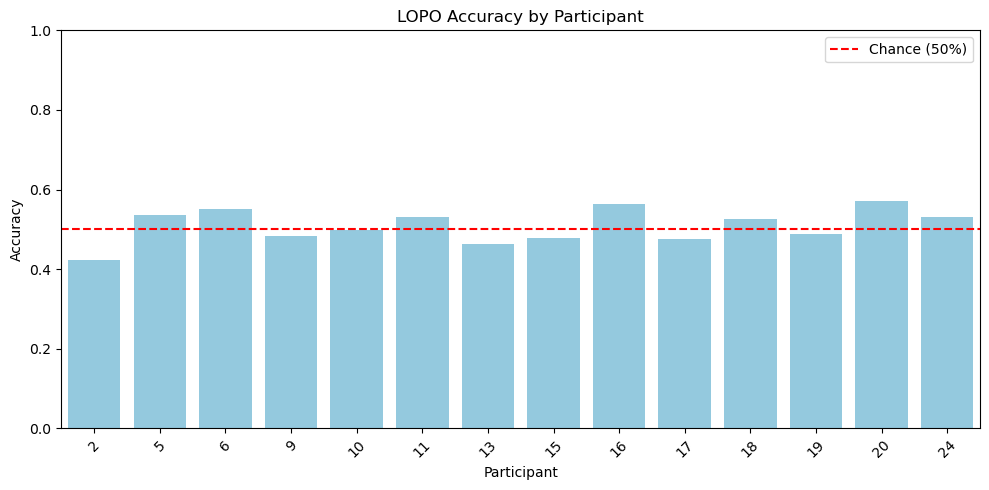

In [27]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp, wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Save directory
SAVE_DIR = "results"
os.makedirs(SAVE_DIR, exist_ok=True)

# === Example Inputs (Replace with your real ones) ===
# participant_ids = [...]  # list of str/int
# accuracies = [...]       # list of float

# === Create Results DataFrame ===
results_df = pd.DataFrame({
    "participant": participant_list,
    "accuracy": accuracies
})

# === Save Results ===
results_path = os.path.join(SAVE_DIR, "lopo_accuracy_by_participant.csv")
results_df.to_csv(results_path, index=False)
print(f"Saved LOPO accuracy results to: {results_path}")

# === Summary Statistics ===
mean_acc = results_df["accuracy"].mean()
std_acc = results_df["accuracy"].std()
print(f"\nMean Accuracy: {mean_acc:.4f}, Std: {std_acc:.4f}")

# === Statistical Significance Tests ===
chance = 0.5
print("\n--- Significance Tests vs. Chance (50%) ---")

# One-sample t-test
t_stat, t_p = ttest_1samp(results_df["accuracy"], popmean=chance)
print(f"One-sample t-test: t={t_stat:.3f}, p={t_p:.4f}")

# Wilcoxon signed-rank test (non-parametric)
try:
    w_stat, w_p = wilcoxon(results_df["accuracy"] - chance)
    print(f"Wilcoxon signed-rank test: W={w_stat:.3f}, p={w_p:.4f}")
except ValueError:
    print("Wilcoxon test failed (possibly all values identical)")

# === Identify Low Performers ===
low_performers = results_df[results_df["accuracy"] < chance]
print(f"\nLow-Performing Participants (<50%): {len(low_performers)}")
print(low_performers.sort_values("accuracy"))

# === Save Low Performers List ===
low_path = os.path.join(SAVE_DIR, "low_performing_participants.csv")
low_performers.to_csv(low_path, index=False)

# === Optional Plot ===
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="participant", y="accuracy", color='skyblue')
plt.axhline(y=chance, color='red', linestyle='--', label="Chance (50%)")
plt.title("LOPO Accuracy by Participant")
plt.ylabel("Accuracy")
plt.xlabel("Participant")
plt.ylim(0, 1)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plot_path = os.path.join(SAVE_DIR, "lopo_accuracy_plot.png")
plt.savefig(plot_path)
print(f"\nSaved plot to: {plot_path}")
plt.show()


In [ ]:
if True:

    binary_results_empty = {
        "Classifier": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "Class0 Recall": [],
        "Class1 Recall": [],
        "Class0 Precision": [],
        "Class1 Precision": [],
        "Class0 F1": [],
        "Class1 F1": [],
        "Macro F1": [],
        "Macro Recall": [],
        "Macro Precision": [],
        "TrainParticipants": [],
        "TestParticipants": [],
        "TrainConditions": [],
        "TestConditions": [],
        "Experiment": [],
        "RandomState": random_state
    }